![BannerAA_Notebooks.png](attachment:497865ac-0f71-47b4-b7f8-3bd33c0e8c4d.png)


# Competencia — Aprendizaje de Máquina 2026-10
## Parte 1: Clasificación de Textos con Machine Learning Clásico

En este notebook abordaremos el problema de clasificación de textos según su **década de origen**. El objetivo principal es desarrollar un modelo capaz de predecir, dado un párrafo como entrada, la década en la que fue escrito. Trabajaremos exclusivamente con **técnicas clásicas de aprendizaje automático**, sin recurrir a redes neuronales ni arquitecturas profundas.

El dataset contiene textos históricos con señales temporales en el vocabulario, la sintaxis y la estructura del lenguaje. Por tanto, una parte importante del trabajo consiste en **representar adecuadamente el texto** antes de entrenar cualquier modelo. A lo largo del notebook podrás identificar las decisiones de preprocesamiento y su impacto en el desempeño del clasificador.

A continuación se presentan los bloques que se desarrollarán:

1. **Importación de librerías**
2. **Carga y exploración de los datos (EDA)**
3. **Preprocesamiento del texto**
4. **Partición de los datos**
5. **Representación del texto (vectorización)**
6. **Construcción del pipeline y modelos**
7. **Búsqueda de hiperparámetros**
8. **Evaluación y comparación de modelos**
9. **Análisis de importancia de features**
10. **Generación del archivo de respuesta para Kaggle**
11. **Guardado del modelo**

## 1. Importación de Librerías

En esta sección se importan todas las librerías necesarias para el desarrollo del notebook. Se organizan por categoría para facilitar su lectura:

- **Manejo de datos:** `pandas`, `numpy`
- **Procesamiento de texto:** `nltk` para tokenización, stopwords y stemming
- **Vectorización:** `CountVectorizer` y `TfidfVectorizer` de scikit-learn
- **Modelos clásicos:** Regresión Logística, Árbol de Decisión, Random Forest, Naive Bayes y KNN
- **Validación:** `StratifiedKFold` y `GridSearchCV` para búsqueda de hiperparámetros con datos balanceados
- **Métricas:** `f1_score` macro como métrica principal, dado que las clases (décadas) pueden estar desbalanceadas
- **Utilidades:** `scipy.sparse` para combinar representaciones, `joblib` para guardar el modelo entrenado

In [29]:
# ─────────────────────────────────────────────
# INSTALACIÓN AUTOMÁTICA DE DEPENDENCIAS
# ─────────────────────────────────────────────

import subprocess
import sys

def instalar_si_falta(paquete, nombre_import=None):
    """
    Intenta importar un paquete. Si no existe, lo instala automáticamente.
    
    Args:
        paquete: nombre del paquete en pip (ej: 'scikit-learn')
        nombre_import: nombre para importar (ej: 'sklearn'). Si es None, usa 'paquete'
    """
    nombre_import = nombre_import or paquete
    try:
        __import__(nombre_import)
    except ImportError:
        print(f"📦 Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete, "-q"])
        print(f"✅ {paquete} instalado correctamente")

# Instalar dependencias requeridas
dependencias = [
    ('pandas',          'pandas'),
    ('numpy',           'numpy'),
    ('nltk',            'nltk'),
    ('scikit-learn',    'sklearn'),
    ('scipy',           'scipy'),
    ('joblib',          'joblib'),
    ('matplotlib',      'matplotlib'),
    ('seaborn',         'seaborn'),
]

print("🔍 Verificando dependencias...\n")
for paquete, nombre_import in dependencias:
    instalar_si_falta(paquete, nombre_import)

print("\n✅ Todas las dependencias están disponibles\n")

🔍 Verificando dependencias...


✅ Todas las dependencias están disponibles



In [41]:
# ─────────────────────────────────────────────
# 1. IMPORTACIÓN DE LIBRERÍAS
# ─────────────────────────────────────────────

# Manejo de datos
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# ── Preprocesamiento de texto ──
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)

# ── Vectorización ──
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Partición y validación ──
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

# ── Pipeline y transformadores ──
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer

# ── Modelos clásicos (Parte 1 — sin deep learning) ──
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import LinearSVC
from sklearn.naive_bayes     import MultinomialNB, ComplementNB
from sklearn.neighbors       import KNeighborsClassifier

# ── Métricas ──
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

# ── Utilidades ──
from scipy.sparse import hstack, csr_matrix
import joblib

# ── Visualización ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_selection import SelectKBest, chi2
from scipy.stats import loguniform

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


## 2. Carga y Exploración de los Datos (EDA)

Antes de construir cualquier modelo, es fundamental entender la estructura y calidad de los datos. En esta sección verificamos:

- **Completitud:** presencia de valores nulos
- **Unicidad:** textos duplicados que podrían inflar el desempeño
- **Validez:** rangos coherentes en la variable objetivo `decade`
- **Balance de clases:** distribución de textos por década, ya que un desbalance significativo afecta la elección de la métrica y la estrategia de entrenamiento

El dataset contiene dos archivos:
- `train.csv`: textos etiquetados con su década de origen (variable `decade` expresada como los tres primeros dígitos del año, por ejemplo `157` para la década de 1570)
- `eval.csv`: textos sin etiqueta sobre los cuales se generarán las predicciones para Kaggle

In [31]:
# ─────────────────────────────────────────────
# 2. CARGA Y EXPLORACIÓN DE DATOS (EDA)
# ─────────────────────────────────────────────

# ── Carga de archivos ──
df_train = pd.read_csv('./Data/train.csv')
df_eval  = pd.read_csv('./Data/eval.csv')

# Copia de trabajo para no modificar los datos originales
data = df_train.copy()

# ── Dimensiones ──
print(f"{'Train shape:':<20} {df_train.shape}")
print(f"{'Eval shape:':<20} {df_eval.shape}")

# ── Primeras filas ──
print("\n── Primeras filas del conjunto de entrenamiento ──")
display(df_train.head())

Train shape:         (31403, 2)
Eval shape:          (3490, 2)

── Primeras filas del conjunto de entrenamiento ──


,text,decade
0,\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Ponte...,164
1,"gone. Sus amigos , sus clientes, todo \r\ncuan...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\r\nlos que panden macho ; y \r\notros e...,166


El conjunto de entrenamiento cuenta con **31.403 textos** y 2 columnas (`text`, `decade`). El conjunto de evaluación tiene **3.490 textos**. Ambos datasets están correctamente estructurados.

In [32]:
# ─────────────────────────────────────────────
# 2.1 Revisión de calidad
# ─────────────────────────────────────────────
print("\n── Tipos de datos ──")
print(df_train.dtypes)

print("\n── Valores nulos por columna ──")
print(df_train.isnull().sum())

print("\n── Textos duplicados ──")
n_dup = df_train['text'].duplicated().sum()
print(f"Duplicados en 'text': {n_dup}")


── Tipos de datos ──
text        str
decade    int64
dtype: object

── Valores nulos por columna ──
text      0
decade    0
dtype: int64

── Textos duplicados ──
Duplicados en 'text': 51


No hay valores nulos en ninguna columna. Se detectaron **51 textos duplicados** (<0.2% del total), los cuales serán eliminados en preprocesamiento para evitar que el mismo texto aparezca en entrenamiento y validación simultáneamente. La variable `decade` cubre desde **150** (década de 1500) hasta **188** (década de 1880), con **39 clases únicas**, confirmando que estamos ante un problema de **clasificación multiclase** de alta granularidad.

In [33]:
# ─────────────────────────────────────────────
# 2.2 Distribución de clases
# ─────────────────────────────────────────────
decade_counts = df_train['decade'].value_counts().sort_index()

print("\n── Distribución de décadas ──")
print(decade_counts.to_string())

print(f"\nNúmero de clases únicas: {df_train['decade'].nunique()}")
print(f"Década más antigua:      {df_train['decade'].min()}")
print(f"Década más reciente:     {df_train['decade'].max()}")


── Distribución de décadas ──
decade
150    786
151    812
152    785
153    775
154    830
155    836
156    792
157    827
158    778
159    802
160    848
161    787
162    808
163    827
164    804
165    814
166    779
167    831
168    822
169    771
170    833
171    816
172    842
173    802
174    807
175    817
176    754
177    782
178    831
179    809
180    825
181    795
182    808
183    794
184    802
185    803
186    773
187    787
188    809

Número de clases únicas: 39
Década más antigua:      150
Década más reciente:     188


La distribución de textos por década es **notablemente uniforme**: todas las clases tienen entre 750 y 850 ejemplos, sin ninguna categoría dominante ni subrepresentada. Esto es favorable para el entrenamiento, aunque con 39 clases el problema sigue siendo desafiante. Usaremos `f1_macro` como métrica principal para tratar todas las décadas por igual, y `stratify=y` en la partición para preservar esta distribución.

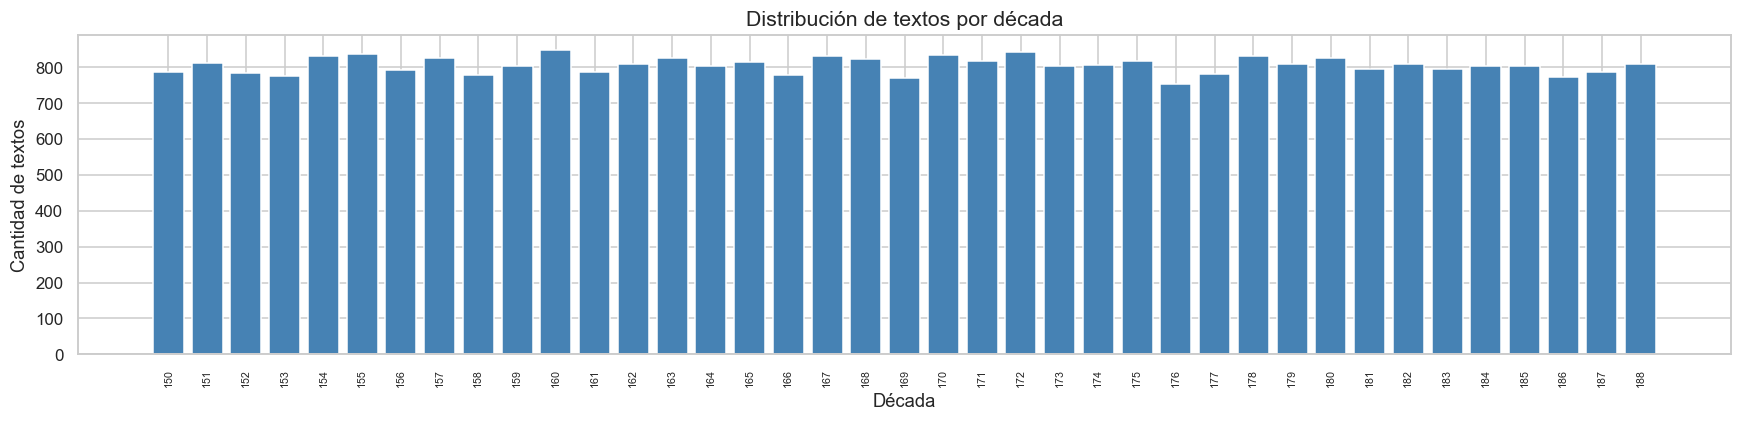

In [34]:
# ─────────────────────────────────────────────
# 2.3 Visualización distribución de clases
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(decade_counts.index.astype(str), decade_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Distribución de textos por década', fontsize=14)
ax.set_xlabel('Década')
ax.set_ylabel('Cantidad de textos')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

La distribución de textos por década es **notablemente uniforme**: todas las clases tienen entre 750 y 850 ejemplos aproximadamente, sin ninguna categoría dominante ni subrepresentada. Las décadas con más ejemplos son **160** (~848) y **155** (~836), mientras que las menos representadas son **176** (~752) y **169** (~771), pero la diferencia entre la clase más grande y la más pequeña es de apenas ~100 textos. Esto es favorable para el entrenamiento ya que no será necesario aplicar técnicas de balanceo como oversampling. Sin embargo, con **39 clases** el problema sigue siendo desafiante — el azar equivale a un accuracy de apenas **~2.6%**. Por esto usaremos `f1_macro` como métrica principal para tratar todas las décadas por igual, y `stratify=y` en la partición train/test para preservar esta distribución uniforme en ambos conjuntos.


── Estadísticas de longitud de textos ──
       text_len  word_count
count   31403.0     31403.0
mean      530.1        82.3
std       539.6        82.4
min       120.0         3.0
25%       185.0        30.0
50%       321.0        50.0
75%       655.0       102.0
max      7480.0      1146.0


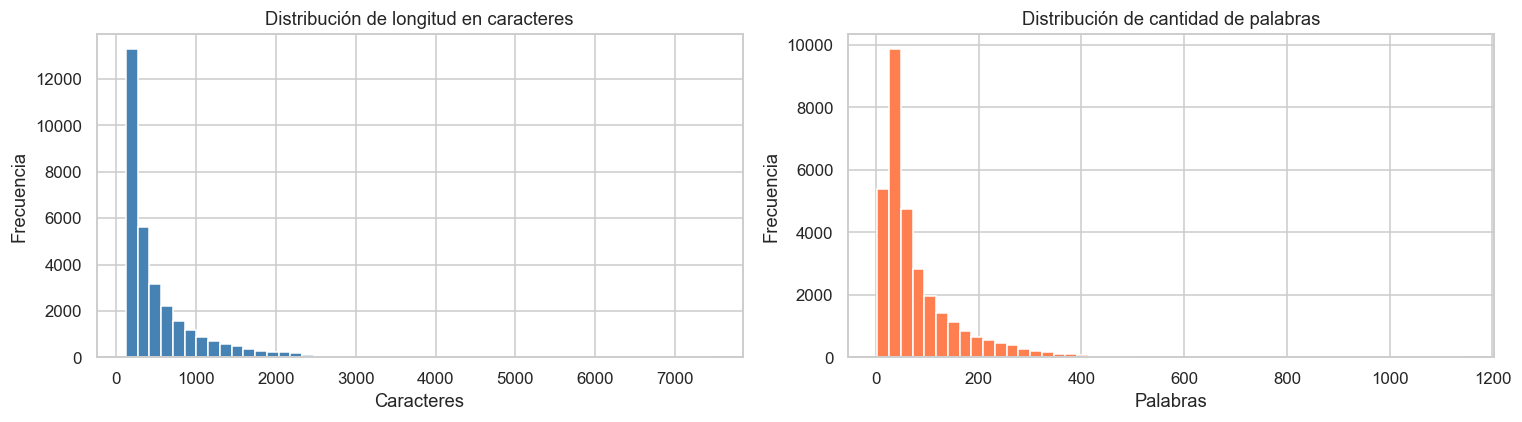

In [35]:
# ─────────────────────────────────────────────
# 2.4 Longitud de los textos
# ─────────────────────────────────────────────
# La longitud del texto puede variar por época (textos medievales más cortos
# por fragmentación de OCR vs. textos modernos más completos)
data['text_len']   = data['text'].str.len()
data['word_count'] = data['text'].str.split().str.len()

print("\n── Estadísticas de longitud de textos ──")
print(data[['text_len', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['text_len'],   bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de longitud en caracteres')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(data['word_count'], bins=50, color='coral',     edgecolor='white')
axes[1].set_title('Distribución de cantidad de palabras')
axes[1].set_xlabel('Palabras')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Ambas distribuciones son **asimétricas a la derecha**: la mayoría de los textos tiene entre 50 y 200 palabras, con una cola de fragmentos más largos de hasta ~1.200 palabras. La brevedad de los textos es un reto para la clasificación ya que con pocos tokens el vocabulario disponible para inferir la época es limitado. Esto refuerza la importancia de complementar la vectorización TF-IDF con features lingüísticas adicionales como longitud de oraciones, riqueza léxica y ratio de puntuación.

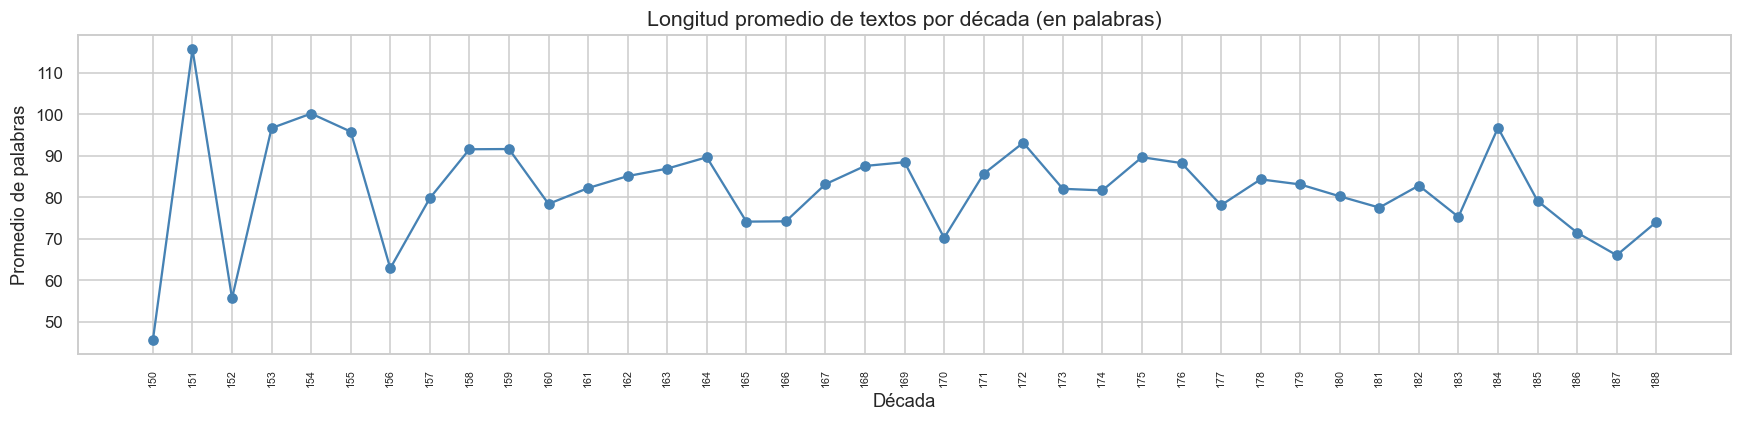

In [36]:
# ─────────────────────────────────────────────
# 2.5 Longitud promedio por década
# ─────────────────────────────────────────────
avg_len = data.groupby('decade')['word_count'].mean().sort_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(avg_len.index.astype(str), avg_len.values, marker='o', color='steelblue', linewidth=1.5)
ax.set_title('Longitud promedio de textos por década (en palabras)', fontsize=14)
ax.set_xlabel('Década')
ax.set_ylabel('Promedio de palabras')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

La longitud promedio oscila entre ~48 y ~115 palabras sin una tendencia temporal clara, lo que indica que la longitud depende más del tipo de fragmento digitalizado que de una evolución histórica sistemática. Por tanto, no es un predictor confiable de la época por sí sola, pero puede aportar como feature auxiliar combinada con otras señales lingüísticas.

## 3. Limpieza básica

In [37]:
# ─────────────────────────────────────────────
# 3.1 LIMPIEZA INICIAL
# ─────────────────────────────────────────────

# Verificar columnas disponibles
print("Columnas train:", data.columns.tolist())
print("Columnas eval: ", df_eval.columns.tolist())

# Eliminar duplicados detectados en el EDA
data = data.drop_duplicates(subset='text').reset_index(drop=True)
print(f"\nRegistros tras eliminar duplicados: {len(data)}")

# Mejor no usar steming porque puede dañar
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'\d+', ' NUM ', texto)  
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

data['text'] = data['text'].apply(limpiar_texto)
df_eval['text'] = df_eval['text'].apply(limpiar_texto)

Columnas train: ['text', 'decade', 'text_len', 'word_count']
Columnas eval:  ['id', 'text']

Registros tras eliminar duplicados: 31352


## Agregación de features linguísticas manualmente

In [38]:
class FeaturesLinguisticas(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    
    def transform(self, X):
        feats = []
        for texto in X:
            palabras = texto.split()
            oraciones = re.split(r'[.!?;]', texto)
            oraciones = [o for o in oraciones if len(o.strip()) > 0]
            
            n_palabras = len(palabras)
            n_chars = len(texto)
            n_oraciones = max(len(oraciones), 1)
            palabras_unicas = len(set(palabras))
            
            feats.append([
                n_palabras,                                          # longitud
                n_chars / max(n_palabras, 1),                        # longitud promedio de palabra
                n_palabras / n_oraciones,                            # longitud promedio de oración
                palabras_unicas / max(n_palabras, 1),                # riqueza léxica (TTR)
                texto.count(',') / max(n_palabras, 1),               # densidad de comas
                sum(1 for c in texto if c.isupper()) / max(n_chars, 1),  # ratio de mayúsculas
            ])
        return np.array(feats)

## Pequeño pipeline vectorización para grid

In [39]:
pipeline = Pipeline([
    ('features', FeatureUnion([
        ('word', TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2), min_df=3, max_df=0.85)),
        ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5), sublinear_tf=True, max_features=25000)),
        ('ling', Pipeline([                          # ← Nueva rama
            ('extractor', FeaturesLinguisticas()),
            ('scaler', MaxAbsScaler())               # Escalar para que no dominen
        ]))
    ])),
    ('selector', SelectKBest(chi2, k=30000)),
    ('clf', LogisticRegression(max_iter=2000, C=1.0, solver='saga', n_jobs=-1))
])

## GridSearch

In [52]:
param_grid = {
    # Word vectorizer — un solo ngram_range elimina la mitad de combinaciones
    'features__word__ngram_range': [(1, 2)],
    'features__word__max_features': [8000, 12000],
    
    # Char vectorizer — un solo ngram_range elimina la mitad de combinaciones
    'features__char__ngram_range': [(2, 6)],
    'features__char__max_features': [10000, 15000],
    
    # Modelo — rango más informativo alrededor de valores bajos
    'clf__C': [0.1, 0.5, 1],

    # k — un solo valor elimina un tercio de combinaciones
    'selector__k': [15000]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=3
)

# Split
X_train, X_val, y_train, y_val = train_test_split(
    data['text'],
    data['decade'],
    test_size=0.2,
    random_state=42,
    stratify=data['decade']
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
preds_val = best_model.predict(X_val)

print("Mejores parámetros:", grid.best_params_)
print("Validation Accuracy:", round(accuracy_score(y_val, preds_val), 4))
print("CV Accuracy:", round(grid.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros: {'clf__C': 1, 'features__char__max_features': 10000, 'features__char__ngram_range': (2, 6), 'features__word__max_features': 12000, 'features__word__ngram_range': (1, 2), 'selector__k': 15000}
Validation Accuracy: 0.2358
CV Accuracy: 0.2273


### Predicción con grid

In [ ]:
preds = best_model.predict(df_eval['text'])

df_submission = df_eval.copy()
df_submission['answer'] = preds

df_submission[['id', 'answer']].to_csv('submission_15_grid.csv', index=False)

## Random

In [42]:
param_dist = {
    # Word vectorizer
    'features__word__ngram_range': [(1,1), (1,2)],
    'features__word__max_features': [10000, 20000],
    
    # Char vectorizer
    'features__char__ngram_range': [(2,5), (3,5)],
    'features__char__max_features': [15000, 25000],
    
    # Modelo
    'clf__C': loguniform(0.1, 10),

    # k
    'selector__k': [20000, 30000, 50000]
}

search = RandomizedSearchCV(
    pipeline,
    param_dist,
    n_iter=12,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=3,
    random_state=42,
    refit=True
)

# Split
X_train, X_val, y_train, y_val = train_test_split(
    data['text'],
    data['decade'],
    test_size=0.2,
    random_state=42,
    stratify=data['decade']
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
preds_val = best_model.predict(X_val)

print("Mejores parámetros:", search.best_params_)
print("Validation Accuracy:", round(accuracy_score(y_val, preds_val), 4))
print("CV Accuracy:", round(search.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros: {'clf__C': np.float64(2.32555726240368), 'features__char__max_features': 25000, 'features__char__ngram_range': (2, 5), 'features__word__max_features': 20000, 'features__word__ngram_range': (1, 1), 'selector__k': 50000}
Validation Accuracy: 0.2414
CV Accuracy: 0.2358


### Predicción con random

In [ ]:
preds = best_model.predict(df_eval['text'])

df_submission = df_eval.copy()
df_submission['answer'] = preds

df_submission[['id', 'answer']].to_csv('submission_16_rs2.csv', index=False)

## Linear SVC

In [ ]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import MaxAbsScaler
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import re

# ── Features lingüísticas históricas ──────────────────────────────────────────
class FeaturesLinguisticas(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        feats = []
        for texto in X:
            palabras = texto.split()
            oraciones = [o for o in re.split(r'[.!?;]', texto) if o.strip()]
            n_pal     = max(len(palabras), 1)
            n_chars   = max(len(texto), 1)
            n_or      = max(len(oraciones), 1)
            feats.append([
                n_pal,                                           # longitud
                n_chars / n_pal,                                 # long. promedio palabra
                n_pal / n_or,                                    # long. promedio oración
                len(set(palabras)) / n_pal,                      # riqueza léxica (TTR)
                texto.count(',')  / n_pal,                       # densidad comas
                texto.count(';')  / n_pal,                       # densidad punto y coma
                texto.count(':')  / n_pal,                       # densidad dos puntos
                sum(1 for c in texto if c.isupper()) / n_chars,  # ratio mayúsculas
                sum(1 for p in palabras if len(p) > 10) / n_pal, # palabras muy largas
                sum(1 for p in palabras if len(p) <= 3) / n_pal, # palabras muy cortas
            ])
        return np.array(feats)

# ── Pipeline ───────────────────────────────────────────────────────────────────
pipeline_svc = Pipeline([
    ('features', FeatureUnion([

        ('word_12', TfidfVectorizer(   # bigramas — señal semántica general
            sublinear_tf=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            max_features=150000
        )),

        ('word_3', TfidfVectorizer(    # trigramas — frases y construcciones históricas
            sublinear_tf=True,
            ngram_range=(3, 3),
            min_df=2,
            max_df=0.95,
            max_features=100000
        )),

        ('char', TfidfVectorizer(      # char n-gramas — morfología multilenguaje
            analyzer='char_wb',
            ngram_range=(2, 6),
            sublinear_tf=True,
            min_df=2,
            max_features=150000
        )),

        ('ling', Pipeline([            # features lingüísticas históricas
            ('extractor', FeaturesLinguisticas()),
            ('scaler', MaxAbsScaler())
        ]))
    ])),

    ('clf', LinearSVC(
        max_iter=10000,
        C=0.1,                        # regularización fuerte para alta dimensión
        class_weight='balanced'
    ))
])

pipeline_svc.fit(X_train, y_train)
preds_val_svc = pipeline_svc.predict(X_val)

print("LinearSVC — Accuracy:", round(accuracy_score(y_val, preds_val_svc), 4))

# Comparación
preds_val_best = best_model.predict(X_val)
print("Modelo anterior — Accuracy:", round(accuracy_score(y_val, preds_val_best), 4))

LinearSVC — Accuracy: 0.2499
Modelo anterior — Accuracy: 0.2414


### Predicción SVC

In [ ]:
preds_svc = pipeline_svc.predict(df_eval['text'])

df_submission = df_eval.copy()
df_submission['answer'] = preds_svc

df_submission[['id', 'answer']].to_csv('submission_svc.csv', index=False)
print("Submission guardado: submission_17_svc.csv")